KNN ile sınıflandırma
Teorik mantık

KNN, yeni bir müşterinin kendisine en yakın müşterilere bakarak karar verir.

Örneğin yeni müşteri:

gelir = 60000
yaş = 30
borç = 9000
kredi puanı = 640

Bu müşteriye en benzeyen 3 kişi:

2 tanesi onay aldı
1 tanesi red aldı

ise model çoğunluğa bakarak onay tahmini yapar.

In [17]:
import pandas as pd

data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)
print(df)

    gelir  yas  mevcut_borc  kredi_puani  sonuc
0   32000   22        18000          480      0
1   45000   25        12000          520      0
2   58000   27        10000          610      1
3   62000   30         9000          640      1
4   29000   21        15000          450      0
5   70000   35         8000          700      1
6   52000   28        14000          590      0
7   81000   40         5000          760      1
8   47000   26        11000          560      0
9   90000   45         4000          790      1
10  61000   31         9500          650      1
11  38000   24        17000          500      0
12  55000   29        13000          600      1
13  73000   38         6000          720      1
14  34000   23        16000          490      0
15  68000   34         7000          690      1
16  49000   27        12500          570      0
17  76000   39         5500          740      1
18  43000   25        14500          530      0
19  64000   33         8500          660

Özellikler ve hedef değişkenin ayrılması

Makine öğrenmesinde önce girişler ve hedef ayrılır.

X → bağımsız değişkenler
y → hedef değişken

In [18]:
X = df[["gelir", "yas", "mevcut_borc", "kredi_puani"]]
y = df["sonuc"]

Eğitim ve test verisinin ayrılması

Bir modelin gerçekten öğrenip öğrenmediğini görmek için veri ikiye ayrılır:

eğitim verisi → modelin öğrendiği bölüm
test verisi → modelin hiç görmediği bölüm

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

KNN ile sınıflandırma

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [21]:
print("=== KNN ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("Classification Report:")
print(classification_report(y_test, knn_pred))

=== KNN ===
Accuracy: 1.0
Confusion Matrix:
[[5 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



Accuracy neden tek başına yeterli değildir?

Accuracy şu formülle hesaplanır:

Accuracy=Doğru Tahmin SayısıToplam Tahmin Sayısı
Accuracy=
Toplam Tahmin Sayısı
Doğru Tahmin Sayısı
	​


Örneğin 6 test verisinin 5 tanesini doğru bilirse:

Accuracy=5/6=0.83
Accuracy=
6 da 5 doğru​

=0.83

yani %83 doğruluk.

Ancak finansal problemlerde her hata eşit değildir.

Örnek
Gerçekte riskli müşteriye kredi verip onaylamak çok büyük zarar doğurabilir
Güvenilir bir müşteriyi reddetmek de müşteri kaybına neden olabilir

Bu yüzden confusion matrix mutlaka ayrıca incelenmelidir.

In [28]:
yeni_musteri = [[54000, 22, 8500, 670]]
tahmin = knn_model.predict(yeni_musteri)

if tahmin[0] == 1:
    print("Başvuru ONAYLANIR")
else:
    print("Başvuru REDDEDİLİR")

Başvuru ONAYLANIR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


KNN’de önemli teknik nokta: ölçekleme problemi

KNN, uzaklık hesabına dayanır. Burada değişkenlerin değer aralıkları çok farklıysa sorun oluşabilir.

Örneğin:

gelir → 30000–90000
yaş → 20–45
kredi puanı → 450–790

Bu durumda gelir değişkeni uzaklık hesabında daha baskın hale gelebilir. Bu yüzden KNN için çoğu zaman ölçekleme (scaling) gerekir.

Daha doğru KNN kullanımı

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

knn_pipeline.fit(X_train, y_train)
knn_pred = knn_pipeline.predict(X_test)

print("=== Ölçeklenmiş KNN ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("Classification Report:")
print(classification_report(y_test, knn_pred))

=== Ölçeklenmiş KNN ===
Accuracy: 1.0
Confusion Matrix:
[[5 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [30]:
yeni_musteri2 = [[54000, 22, 8500, 670]]
tahmin = knn_model.predict(yeni_musteri2)

if tahmin[0] == 1:
    print("Başvuru ONAYLANIR")
else:
    print("Başvuru REDDEDİLİR")

Başvuru ONAYLANIR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Modelin Ful ve Görsel Hali için:

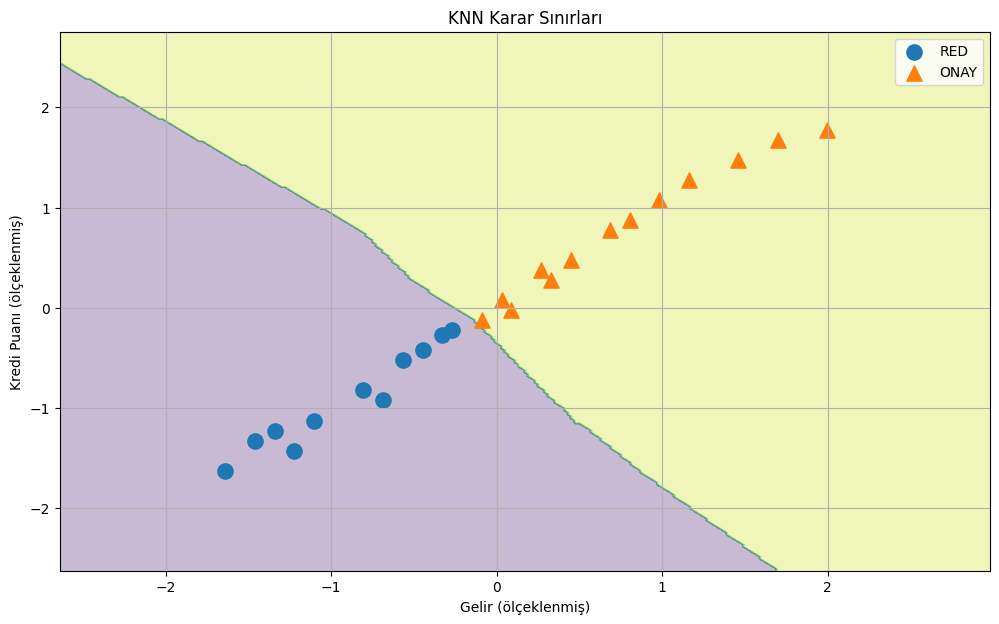

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)

# Görselleştirme için 2 değişken seçiyoruz
X = df[["gelir", "kredi_puani"]].values
y = df["sonuc"].values

# KNN uzaklık tabanlı olduğu için ölçekleme önemli
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

# Karar sınırları için grid oluşturma
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Her grid noktası için tahmin
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Grafik
plt.figure(figsize=(12, 7))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], s=120, marker="o", label="RED")
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], s=120, marker="^", label="ONAY")

plt.xlabel("Gelir (ölçeklenmiş)")
plt.ylabel("Kredi Puanı (ölçeklenmiş)")
plt.title("KNN Karar Sınırları")
plt.legend()
plt.grid(True)
plt.show()